In [1]:
import numpy as np
import matplotlib.pyplot as plt
import hera_filters as hf
import healpy as hp

## Notes

From what i understand from the HERA DPSS Primer, what is happening when using dpss filtering, is that a region is defined in the delay spectra (i am assuming we can apply this to other domains), in the case of HERA they choose a top hat filter (again i am assuming we can choose another, but this was probably picked for a reason). within this region, a matrix operation is applied to the data (we define a dpss filter with a matrix, then take the dagger of that matrix onto the data), resulting in coefficients, these are the dpss modes. the issue with these modes, is that they are not unique, so we use linear least squares to fit for the correct ones. we then apply the original matrix to the resulting dpss modes, giving us our reconstructed data in the original domain using lower samples. in the HERA example, they go from 200 samples down to 24!

DPSS requires uniform spacing, if there are gaps then dpss weighting has to be taken into account

Some conlcusions i've found: 
* dpss will be usefull once i go for a full spectra solve of the maps, it will reduce the number of maps to solve for
* i dont think i can reduce the pixel amount for the maps, i can use dpss on sections of the maps, but going for the full sphere shows that spherical harmonics reduce the parameters by the same amount

Some math:

$A_{ij} = e^{2\pi i(t_i - t_c)fc}D_j(t_i;\Delta=n_f\delta t \Delta f)$

## Exploring

In [2]:
m_th = np.load('/home/dominiv/eigsep/my_notebooks/july2025/beam_maps/beam_th.npy')
m_ph = np.load('/home/dominiv/eigsep/my_notebooks/july2025/beam_maps/beam_ph.npy')
m_dummy = np.ones_like(m_th)

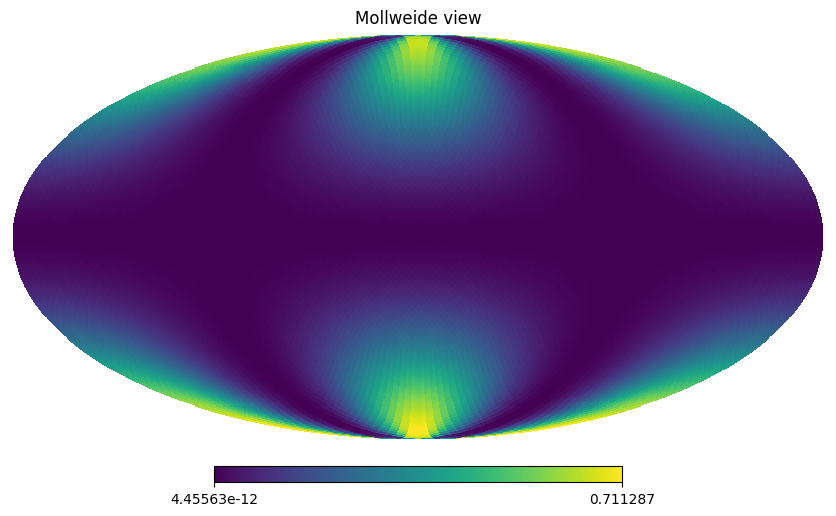

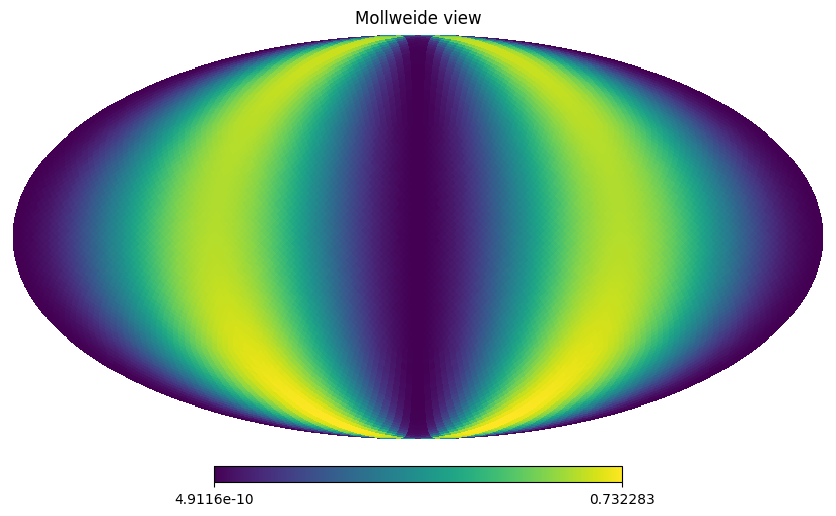

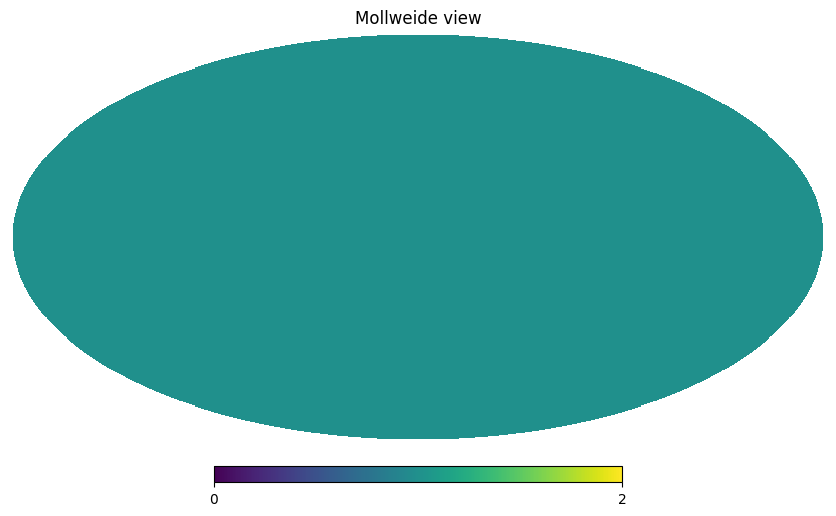

In [3]:
hp.mollview(m_th[0])
hp.mollview(m_ph[0])
hp.mollview(m_dummy[0])

In [8]:
N_freq = 10
test_m = hp.ud_grade(m_th[:N_freq, :], 8)
N_pix = test_m.shape[1]

/tmp/ipykernel_7315/2605158660.py:3: RuntimeWarning: divide by zero encountered in power
  foreground = freqs**(-.22) + 1000


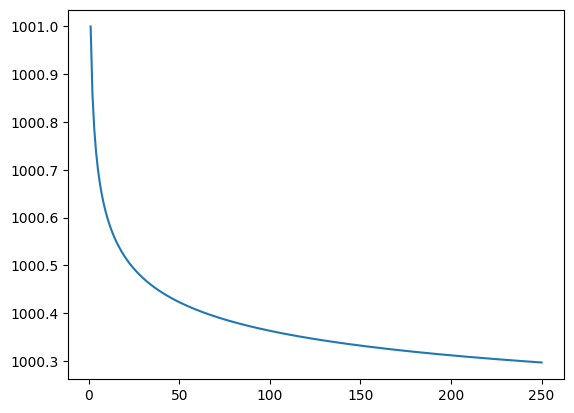

(251,)


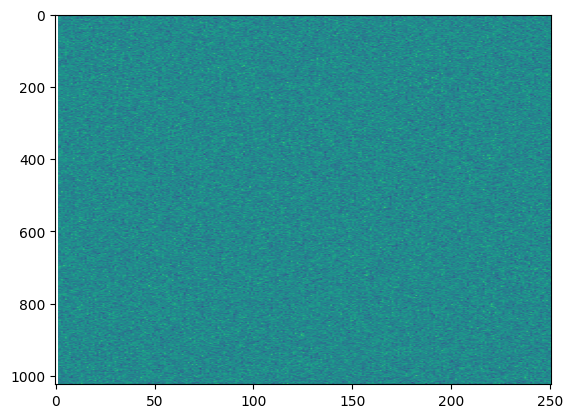

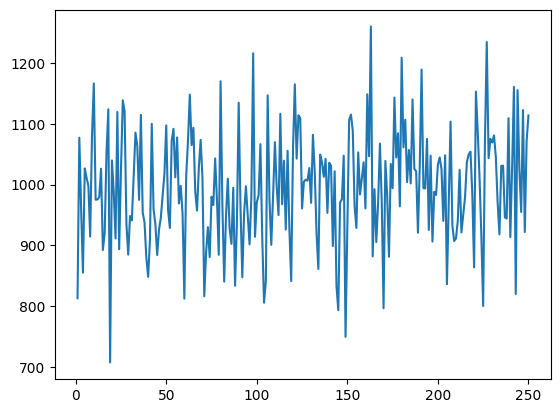

In [97]:
times = np.linspace(0, 3600, 1024)
freqs = np.linspace(0, 250, 251)
foreground = freqs**(-.22) + 1000
def spectra(times, freqs, sky, level=100):
    spec = np.zeros((times.shape[0], freqs.shape[0]))
    print(sky.shape)
    for i in range(spec.shape[0]):
        spec[i] += sky + np.random.normal(loc=0, scale=level, size=(freqs.size))
    return spec
    # data = sky + np.random.normal(loc=0, scale=level)
    

# f1 = 60e6
# f2 = 80e6

# signal = np.sin(2*np.pi*times * f1) + np.sin(2 * np.pi * times * f2)

plt.figure()
plt.plot(freqs, foreground)
plt.show()

data = spectra(times, freqs, foreground)

plt.figure()
plt.imshow(data, aspect='auto')
plt.show()
plt.figure()
plt.plot(freqs, data[0])
# plt.xlim(50, 55)
plt.show()

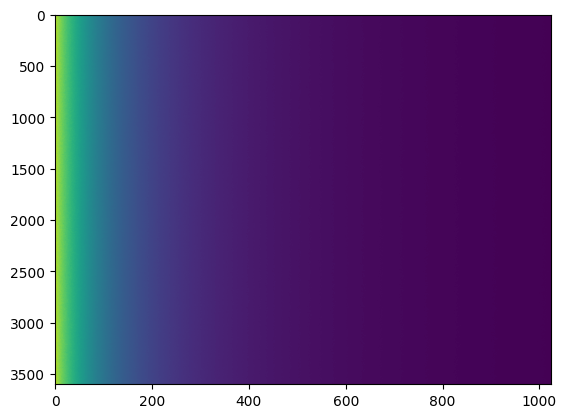

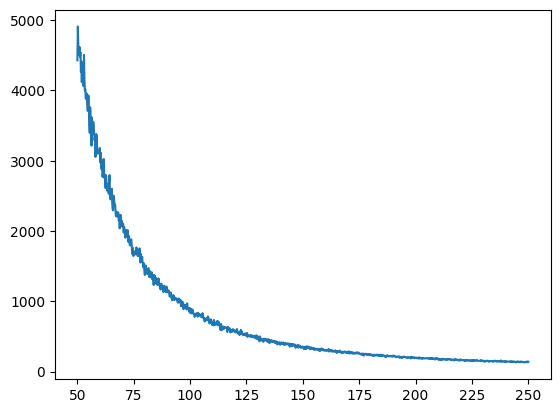

In [4]:

times = np.linspace(0, 3600, 3600)          # seconds
freqs = np.linspace(50, 250, 1024)           # MHz (avoid 0)

def galactic_foreground(freqs, A=300, nu0=150.0, beta=-2.5, T_rcv=50.0):
    """
    Toy model in Kelvin-ish units:
    T_sky = A * (nu/nu0)^beta + T_rcv
    """
    return A * (freqs / nu0)**beta + T_rcv

def spectra(times, freqs, sky, t_int=1.0, delta_nu=1e3):
    """
    Add simple radiometer noise per time x freq:
    sigma ~ Tsys / sqrt(delta_nu * t_int)
    """
    sky = np.asarray(sky)
    Tsys = sky  # (toy) assume system temp dominated by sky
    sigma = Tsys / np.sqrt(delta_nu * t_int)  # shape: (nfreq,)
    noise = np.random.normal(0, sigma, size=(times.size, freqs.size))
    return sky[None, :] + noise

sky = galactic_foreground(freqs)
spec = spectra(times, freqs, sky)

plt.figure()
plt.imshow(spec, aspect='auto')
plt.show()

plt.figure()
plt.plot(freqs, spec[0])
plt.show()

In [5]:
a_mat = hf.dspec.dpss_operator(x=freqs, filter_centers=[0], filter_half_widths=[.01], nterms=[24])

In [6]:
from scipy.signal import windows
def Amat(x, nterms, fc, fhw):
    """
    Parameters
    ----------
    x : frequencies
    nterms : number of dpss modes to fit
    fc : filter center (inverse frequency units)
    fhw : filter half width (inverse frequency units)

    Returns
    -------
    A : design matrix
    
    """
    nf = x.size  # number of frequencies
    bandwidth = x[-1] - x[0]
    xc = x[nf // 2]  # center frequency
    exp_arg = 2j * np.pi * (x[:, None] - xc) * fc
    dpss = windows.dpss(nf, bandwidth * fhw, Kmax=nterms).T
    return dpss * np.exp(exp_arg)

def least_squares(A, y):
    """
    Find the solution to Ax = y by minimizing least squares.
    """
    Q, R = np.linalg.qr(A)
    xhat = np.linalg.solve(R, Q.T @ y)
    return xhat

def fit_c(nterms, fc, fhw, x=freqs, y=spec[0]):
    A = Amat(x, nterms, fc, fhw)
    xhat = least_squares(A, y)
    yhat = A @ xhat
    return yhat
def fit_hera(nterms, fc, fhw, x=freqs, y=spec[0]):
    A = hf.dspec.dpss_operator(x=freqs, filter_centers=fc, filter_half_widths=fhw, nterms=nterms)[0]
    # A = Amat(x, nterms, fc, fhw)
    xhat = least_squares(A, y)
    yhat = A @ xhat
    return yhat

def fit_hera_pack(nterms, fc, fhw, weights, x, y):
    A, _ = hf.dspec.dpss_operator(x=x, filter_centers=fc, filter_half_widths=fhw, nterms=nterms)
    coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=A)@y
    hera_model = A@coeff
    return hera_model, coeff

A_mat = Amat(freqs, 24, 0, .01)

In [7]:
# weights = np.ones((freqs.shape[0], freqs.shape[0])) * 1e-2
weights = np.ones_like(freqs)
a_mat, nterm_amount = hf.dspec.dpss_operator(x=freqs, filter_centers=[0], filter_half_widths=[.01], nterms=[24])


coeff = hf.dspec.fit_solution_matrix(weights=weights, design_matrix=a_mat)@spec[0]
hera_model = a_mat@coeff
hera_model.shape

(1024,)

/home/dominiv/venv/jupyter/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/dominiv/venv/jupyter/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


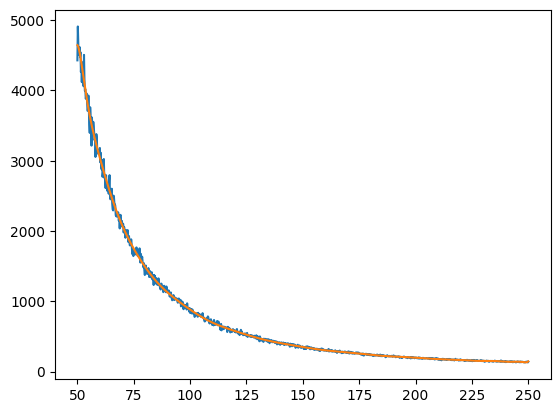

In [8]:
plt.figure()
plt.plot(freqs, spec[0])
plt.plot(freqs, hera_model)
plt.show()

In [157]:
a_mat[0].shape, A_mat.shape

((1024, 24), (1024, 24))

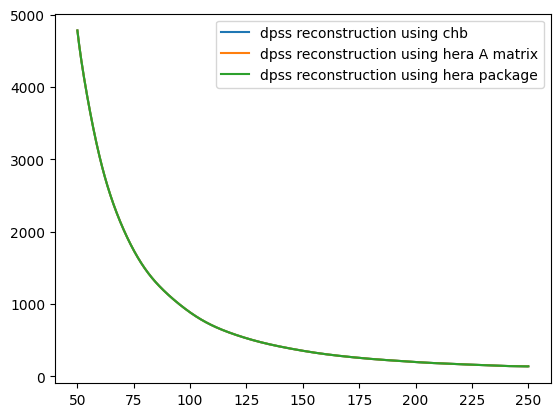

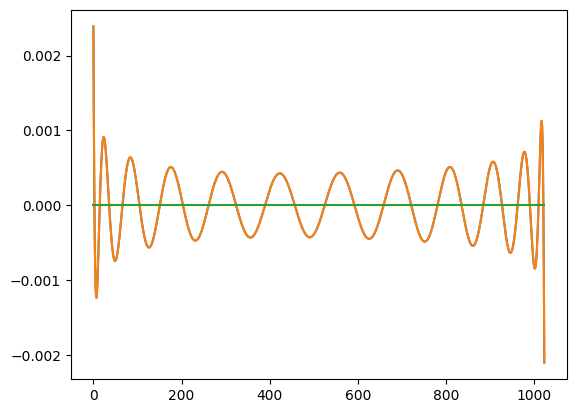

In [261]:
plt.figure()
# plt.plot(freqs, spec[0], label='sim data')
plt.plot(freqs, fit_c(24, 0, .01), label='dpss reconstruction using chb')
plt.plot(freqs, fit_hera([24], [0], [.01], x=freqs, y=spec[0]), label='dpss reconstruction using hera A matrix')
plt.plot(freqs, fit_hera_pack([24], [0], [.01], weights=weights, x=freqs, y=spec[0]), label='dpss reconstruction using hera package')
# plt.plot(freqs, sky)
plt.legend()
plt.show()

plt.figure()
plt.plot(fit_hera([24], [0], [.01], x=freqs, y=spec[0]) - fit_c(24, 0, .01))
plt.plot(fit_hera_pack([24], [0], [.01], weights=weights, x=freqs, y=spec[0]) - fit_c(24, 0, .01))
plt.plot(fit_hera_pack([24], [0], [.01], weights=weights, x=freqs, y=spec[0]) - fit_hera([24], [0], [.01]))
# plt.plot(fit_c(24, 0, .01) - sky)
# plt.plot(fit_hera_pack([24], [0], [.01], weights=weights, x=freqs, y=spec[0]) - spec[0])
# plt.plot(a_mat[0]@least_squares(a_mat[0], spec[0]) - fit(24, 0, .01))
plt.show()

In [24]:
nterms = [14]
fc =     [0]
fhw =    [.01]
# weights = np.ones_like(m_th[0])
xs = np.linspace(0, m_th.shape[1], m_th.shape[1])
map_freq = np.linspace(0, 250, 1024, endpoint=True)
weights = np.ones_like(a=map_freq[::16][12:])


dpss_map, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fhw, weights=weights, x=map_freq[::16][12:], y=m_th)
# dpss_map = fit_c(nterms=nterms[0], fc=fc[0], fhw=fhw[0], x=map_freq[::16][12:], y=m_th)

In [47]:
coeff.shape

(14, 12288)

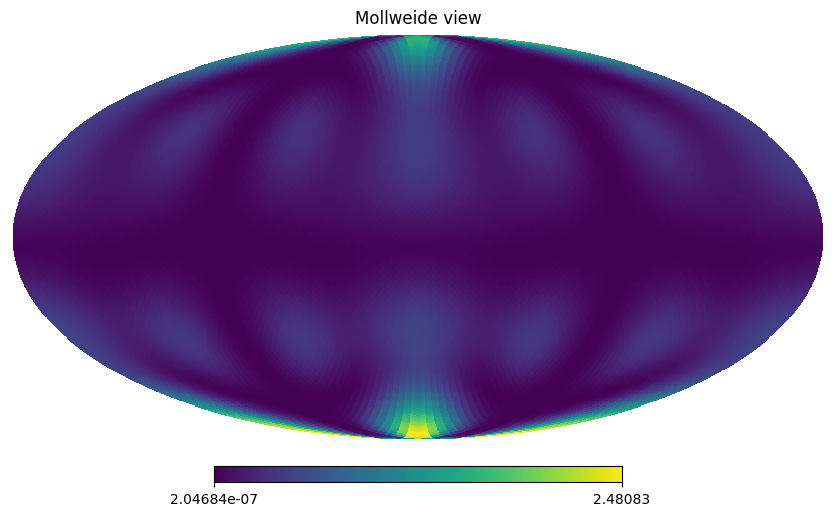

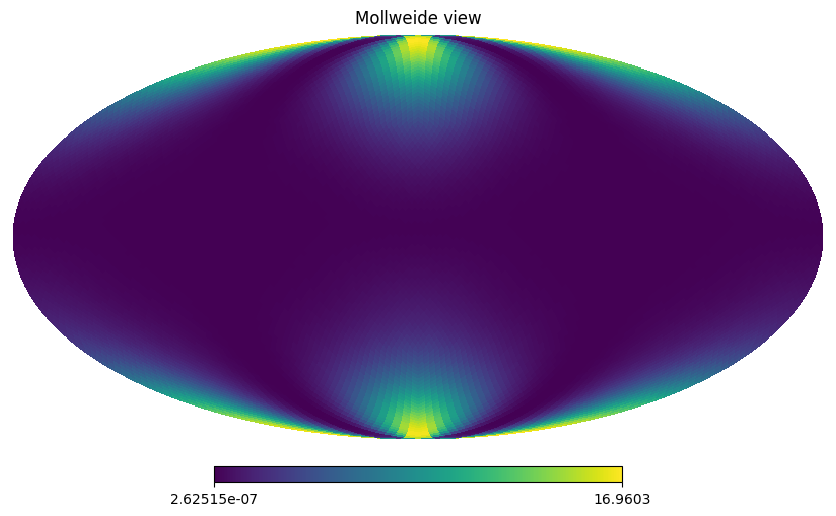

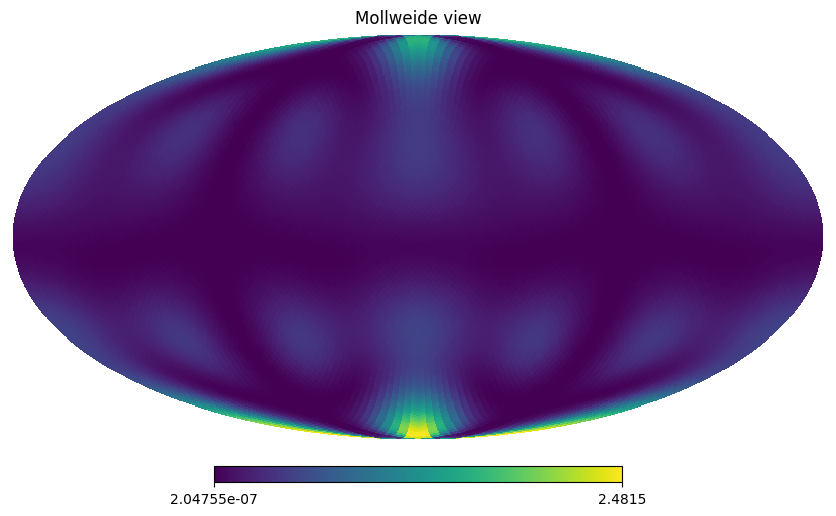

In [28]:
hp.mollview(dpss_map[50])
hp.mollview(coeff[0])
hp.mollview(m_th[50])

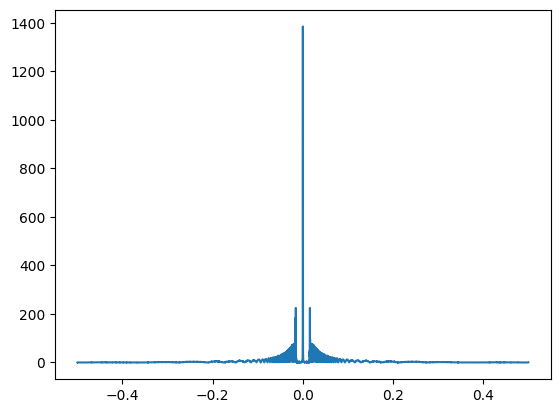

In [11]:
pix_ind = np.linspace(0, m_th[0].shape[0], m_th[0].shape[0])
fft_ind = np.fft.fftfreq(m_th[0].shape[0])

plt.figure()
plt.plot(np.fft.fftshift(fft_ind), np.fft.fftshift(np.abs(np.fft.fft(m_th[0]))))
plt.show()

In [22]:
weights = np.ones_like(a=pix_ind)
nterms = [15]
fc =     [0]
fhw =    [.000001]

dpss_pix, coeff = fit_hera_pack(nterms=nterms, fc=fc, fhw=fhw, weights=weights, x=pix_ind, y=m_th[0])

In [63]:
dpss_pix.shape, coeff.shape

((12288,), (14,))

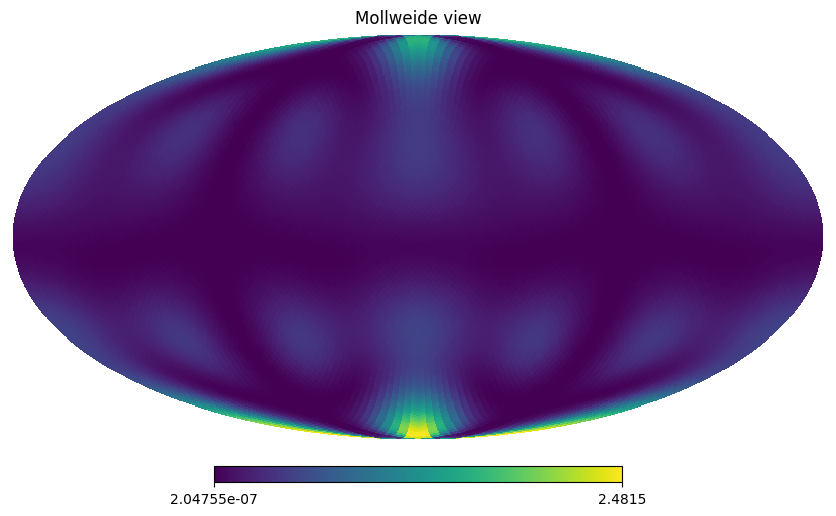

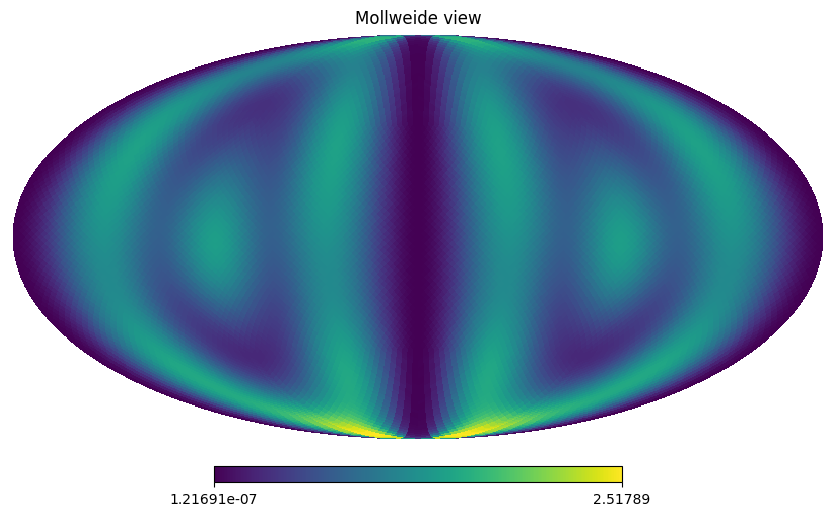

In [35]:
hp.mollview(m_th[50], rot=(0, 0, 0))
hp.mollview(m_ph[50], rot=(0, 0, 0))